In [1]:
# ============================================================================
# Analyze Fine-tuning Loss Curves
# ============================================================================
# This notebook visualizes training and validation loss curves for fine-tuned
# Akita models. It can plot:
# - A single model's loss curve
# - All models from a dataset in separate subplots
# ============================================================================

In [2]:
# %% Setup Python Path
import sys
import os

# Add parent directory to Python path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    print(f"Added to Python path: {parent_dir}")

# %% Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import glob

Added to Python path: /home1/smaruj/pytorch_akita


### Configuration

In [3]:
# Base path for loss files
BASE_PATH = "/scratch1/smaruj/Akita_pytorch_models/finetuned"

# Dataset to analyze
ORGANISM = "mouse"              # "mouse" or "human"
DATASET_NAME = "Hsieh2019_mESC" # Dataset name
NUM_MODELS = 8                  # Number of model splits (0 to NUM_MODELS-1)

# Plotting options
PLOT_SINGLE = False             # If True, plot only a single model
SINGLE_MODEL_IDX = 1            # Which model to plot if PLOT_SINGLE=True
SAVE_FIGURE = False             # Save figure as SVG
OUTPUT_FILE = "/plots/example_finetuning_loss_curves.svg"  # Output filename

In [4]:
# %% Helper Functions

def load_loss_file(organism, dataset_name, model_idx, base_path=BASE_PATH):
    """
    Load loss CSV file for a specific model.
    
    Args:
        organism (str): "mouse" or "human"
        dataset_name (str): Dataset name
        model_idx (int): Model split index
        base_path (str): Base path to finetuned models
    
    Returns:
        pd.DataFrame or None: Loss dataframe or None if file not found
    """
    file_path = (
        f"{base_path}/{organism}_models/{dataset_name}/losses/"
        f"Akita_v2_{organism}_{dataset_name}_model{model_idx}_finetuned.csv"
    )
    
    if not os.path.exists(file_path):
        print(f"Warning: File not found: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None


def find_all_models(organism, dataset_name, base_path=BASE_PATH):
    """
    Find all available model loss files for a dataset.
    
    Args:
        organism (str): "mouse" or "human"
        dataset_name (str): Dataset name
        base_path (str): Base path to finetuned models
    
    Returns:
        list: List of available model indices
    """
    pattern = (
        f"{base_path}/{organism}_models/{dataset_name}/losses/"
        f"Akita_v2_{organism}_{dataset_name}_model*_finetuned.csv"
    )
    
    files = glob.glob(pattern)
    
    # Extract model indices from filenames
    model_indices = []
    for f in files:
        try:
            # Extract number between "model" and "_finetuned"
            basename = os.path.basename(f)
            idx_str = basename.split("model")[1].split("_finetuned")[0]
            model_indices.append(int(idx_str))
        except:
            continue
    
    return sorted(model_indices)


def plot_single_model(df, model_idx, dataset_name):
    """
    Plot loss curves for a single model.
    
    Args:
        df (pd.DataFrame): Loss dataframe
        model_idx (int): Model index
        dataset_name (str): Dataset name
    """
    plt.figure(figsize=(10, 5))
    
    plt.plot(df['Epoch'], df['Train Loss'], 
             label='Train Loss', linewidth=2, marker='o', markersize=3)
    plt.plot(df['Epoch'], df['Validation Loss'], 
             label='Validation Loss', linewidth=2, marker='s', markersize=3)
    
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.title(f'Fine-tuning Loss: {dataset_name} (Model {model_idx})', 
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Find best epoch (minimum validation loss)
    best_epoch = df.loc[df['Validation Loss'].idxmin(), 'Epoch']
    best_val_loss = df['Validation Loss'].min()
    plt.axvline(x=best_epoch, color='red', linestyle=':', 
                label=f'Best (Epoch {best_epoch:.0f})', alpha=0.7)
    plt.legend(fontsize=11)
    
    plt.show()
    
    print(f"Best validation loss: {best_val_loss:.6f} at epoch {best_epoch:.0f}")
    

def plot_all_models(organism, dataset_name, model_indices, base_path=BASE_PATH):
    """
    Plot loss curves for all models in a grid of subplots.
    
    Args:
        organism (str): "mouse" or "human"
        dataset_name (str): Dataset name
        model_indices (list): List of model indices to plot
        base_path (str): Base path to finetuned models
    """
    n_models = len(model_indices)
    
    # Determine grid layout
    n_cols = min(3, n_models)
    n_rows = int(np.ceil(n_models / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    
    # Handle single subplot case
    if n_models == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Track statistics
    all_best_epochs = []
    all_best_losses = []
    
    for i, model_idx in enumerate(model_indices):
        ax = axes[i]
        
        # Load data
        df = load_loss_file(organism, dataset_name, model_idx, base_path)
        
        if df is None:
            ax.text(0.5, 0.5, f'Model {model_idx}\nData not found', 
                   ha='center', va='center', fontsize=12)
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        # Plot
        ax.plot(df['Epoch'], df['Train Loss'], 
               label='Train', linewidth=2, alpha=0.8)
        ax.plot(df['Epoch'], df['Validation Loss'], 
               label='Validation', linewidth=2, alpha=0.8)
        
        # Mark best epoch
        best_epoch = df.loc[df['Validation Loss'].idxmin(), 'Epoch']
        best_val_loss = df['Validation Loss'].min()
        ax.axvline(x=best_epoch, color='red', linestyle=':', alpha=0.5)
        
        all_best_epochs.append(best_epoch)
        all_best_losses.append(best_val_loss)
        
        # Formatting
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Loss (MSE)', fontsize=10)
        ax.set_title(f'Model {model_idx} (Best: {best_val_loss:.5f} @ Epoch {best_epoch:.0f})', 
                    fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.5)
    
    # Hide unused subplots
    for i in range(n_models, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Fine-tuning Loss Curves: {dataset_name}', 
                fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*70)
    print(f"Summary Statistics for {dataset_name}")
    print("="*70)
    print(f"Number of models: {n_models}")
    print(f"Best validation loss: {min(all_best_losses):.6f} (Model {model_indices[np.argmin(all_best_losses)]})")
    print(f"Worst validation loss: {max(all_best_losses):.6f} (Model {model_indices[np.argmax(all_best_losses)]})")
    print(f"Mean validation loss: {np.mean(all_best_losses):.6f} ± {np.std(all_best_losses):.6f}")
    print(f"Mean best epoch: {np.mean(all_best_epochs):.1f} ± {np.std(all_best_epochs):.1f}")
    print("="*70)

### Main Execution

Analyzing Fine-tuning Loss Curves
Organism: mouse
Dataset: Hsieh2019_mESC

Finding all available models...
Found 8 models: [0, 1, 2, 3, 4, 5, 6, 7]



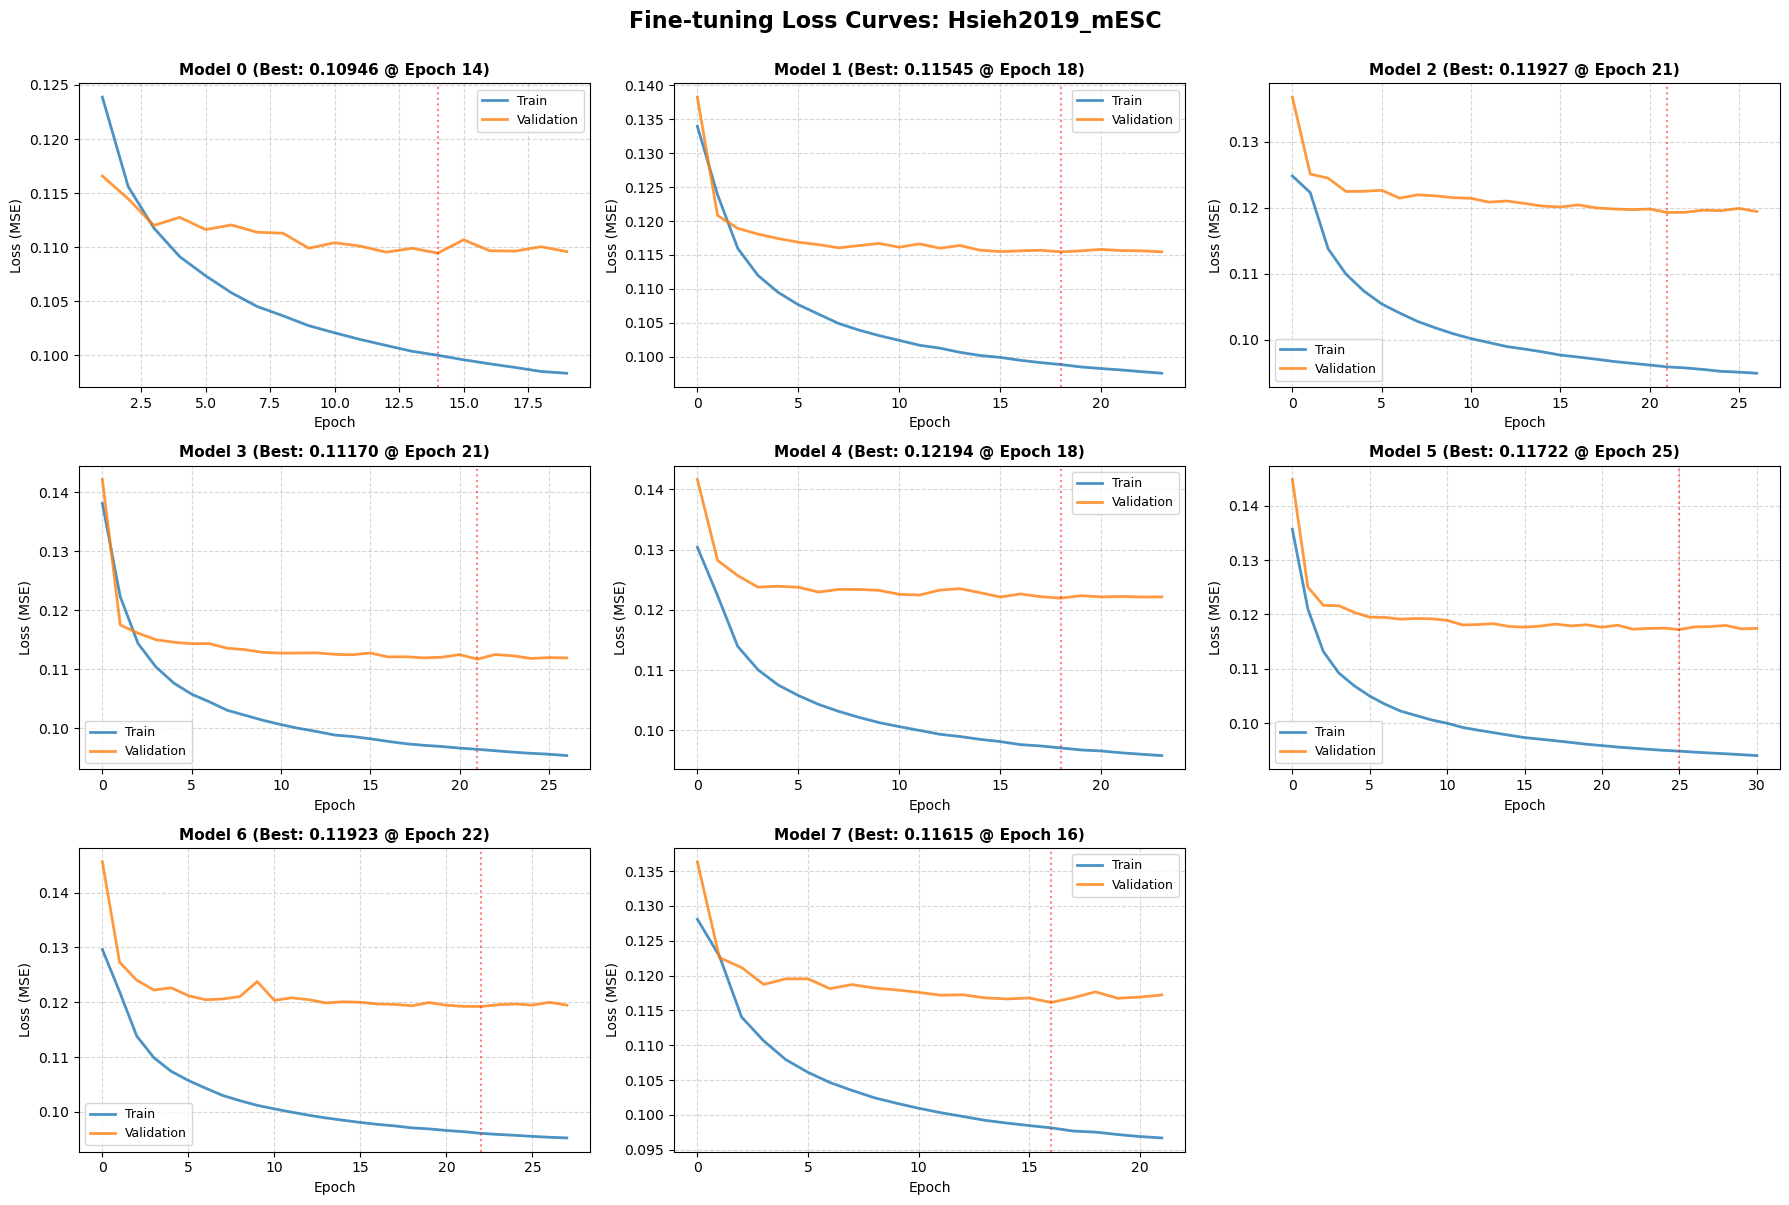


Summary Statistics for Hsieh2019_mESC
Number of models: 8
Best validation loss: 0.109464 (Model 0)
Worst validation loss: 0.121937 (Model 4)
Mean validation loss: 0.116303 ± 0.003852
Mean best epoch: 19.4 ± 3.3

Done!


In [5]:
print("="*70)
print("Analyzing Fine-tuning Loss Curves")
print("="*70)
print(f"Organism: {ORGANISM}")
print(f"Dataset: {DATASET_NAME}")
print("")

if PLOT_SINGLE:
    # Plot single model
    print(f"Plotting single model: {SINGLE_MODEL_IDX}")
    df = load_loss_file(ORGANISM, DATASET_NAME, SINGLE_MODEL_IDX)
    
    if df is not None:
        plot_single_model(df, SINGLE_MODEL_IDX, DATASET_NAME)
        
        if SAVE_FIGURE:
            plt.savefig(OUTPUT_FILE, format='svg', bbox_inches='tight')
            print(f"\n✓ Figure saved to: {OUTPUT_FILE}")
    else:
        print(f"Error: Could not load data for model {SINGLE_MODEL_IDX}")

else:
    # Plot all models
    print("Finding all available models...")
    model_indices = find_all_models(ORGANISM, DATASET_NAME)
    
    if not model_indices:
        print(f"Warning: No models found. Trying models 0 to {NUM_MODELS-1}...")
        model_indices = list(range(NUM_MODELS))
    else:
        print(f"Found {len(model_indices)} models: {model_indices}")
    
    print("")
    plot_all_models(ORGANISM, DATASET_NAME, model_indices)
    
    if SAVE_FIGURE:
        plt.savefig(OUTPUT_FILE, format='svg', bbox_inches='tight')
        print(f"\n✓ Figure saved to: {OUTPUT_FILE}")

print("\nDone!")
